In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr

### Quartiles

In [2]:
def prepare_quantiles(file_path, value_col='cout',start_year=1985, end_year=2015):
    """
    Reads a tab-separated file into a pandas DataFrame with the first column as the index.
    Returns simulation-only quantile and mean data for the specified value column.
    """
    flow = pd.read_csv(file_path, index_col=0, sep='\t', low_memory=False)
    flow = flow.drop(flow.index[0])  # Drop first row if it's a header

    # Ensure index is datetime
    flow.index = pd.to_datetime(flow.index)

    # Trim to date range
    flow = flow.loc[str(start_year):str(end_year)]

    # Convert to float
    flow[value_col] = flow[value_col].astype(float)

    # Extract day of year and year
    flow['day_of_year'] = flow.index.dayofyear
    flow['year'] = flow.index.year

    # Pivot for simulations
    pivoted_sim = flow.pivot_table(values=value_col, index='day_of_year', columns='year')

    # Compute quantiles and mean
    quartiles_sim = pivoted_sim.quantile([0.025, 0.5, 0.975], axis=1)
    mean_sim = pivoted_sim.mean(axis=1)

    return quartiles_sim, pivoted_sim, mean_sim

def prepare_monthly_precip(file_path, value_col='upcprc', start_year=1985, end_year=2015):
    """Returns a list of 12 arrays — one per month — of monthly total precip across years."""
    flow = pd.read_csv(file_path, index_col=0, sep='\t', low_memory=False)
    flow = flow.drop(flow.index[0])
    flow.index = pd.to_datetime(flow.index)
    flow = flow.loc[str(start_year):str(end_year)]
    flow[value_col] = flow[value_col].astype(float)
    monthly = flow[value_col].resample('ME').sum()  # monthly totals
    monthly_df = monthly.to_frame()
    monthly_df['month'] = monthly_df.index.month
    return [monthly_df[monthly_df['month'] == m][value_col].values for m in range(1, 13)]


In [21]:
def process_directory_combined_plot(input_dir, output_path):
    """
    Processes all files starting with '00' and ending with '.txt' in the input directory.
    Creates a single figure: 3 cols × 2 row-pairs (boxplot above streamflow/SWE).
    Vertical lines on the left and right of each pair tie them visually to the same gauge.
    """
    from matplotlib.lines import Line2D
    import matplotlib.patches as mpatches

    hype_id_to_location = {
     #   '58328': ('Milk River', 'BCBMO'),
     #   '58346': ('Milk River', 'BSCMO'),
        '58363': ('Milk River', 'BTCIB'),
     #   '58425': ('Milk River', 'CLCMO'),
        '58290': ('Milk River', 'FRRIB'),
        '58356': ('Milk River', 'LDCIB'),
    #    '58408': ('Milk River', 'MRWIB'),
    #    '58643': ('Milk River', 'NFKMR'),
    #    '58418': ('Milk River', 'PPCMO'),
    #    '58398': ('Milk River', 'RKCMO'),
        '58213': ('St. Mary', 'SMRBB'),
        '58208': ('St. Mary', 'SMRIB'),
    #    '58223': ('St. Mary', 'SWCSB'),
        '58308': ('Milk River', 'MREIB')
    }

    sim_color    = '#e31a1c'
    upsnow_color = '#1f78b4'

    plot_data   = []
    spo_records = []

    for file_name in sorted(os.listdir(input_dir)):
        if file_name.startswith('00') and file_name.endswith('.txt'):
            file_path = os.path.join(input_dir, file_name)
            hype_id = ''.join(filter(str.isdigit, file_name))[-5:]

            if hype_id not in hype_id_to_location:
                continue

            region, gauge_id = hype_id_to_location[hype_id]

            quartiles_sim, pivoted_sim, mean_sim          = prepare_quantiles(file_path, value_col='cout')
            quartiles_upsnow, pivoted_upsnow, mean_upsnow = prepare_quantiles(file_path, value_col='upsnow')
            monthly_precip                                = prepare_monthly_precip(file_path, value_col='upcprc')

            spo_day = SpringPulseOnset(mean_sim)
            spo_records.append({'region': region, 'gauge_id': gauge_id, 'spo_day': spo_day})
            plot_data.append({
                'quartiles_sim':    quartiles_sim,
                'pivoted_sim':      pivoted_sim,
                'mean_sim':         mean_sim,
                'quartiles_upsnow': quartiles_upsnow,
                'pivoted_upsnow':   pivoted_upsnow,
                'mean_upsnow':      mean_upsnow,
                'monthly_precip':   monthly_precip,
                'spo_day':          spo_day,
                'title':            f"{region}: {gauge_id}"
            })

    # Day-of-year for the 1st of each month (non-leap year)
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_labels = ['Jan 1','Feb 1','Mar 1','Apr 1','May 1','Jun 1',
                    'Jul 1','Aug 1','Sep 1','Oct 1','Nov 1','Dec 1']        

    spo_df = pd.DataFrame(spo_records)
    spo_df.to_csv(os.path.join(output_path, 'spring_pulse_onset.csv'), index=False)

    num_plots = len(plot_data)
    ncols = 3
    width, height = 10.5, 11

    mpl.rcParams.update({
        'font.size':       7,
        'axes.labelsize':  7,
        'axes.titlesize':  7,
        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'legend.fontsize': 6,
        'figure.dpi':      300,
        'lines.linewidth': 1.0,
        'xtick.major.pad': 2,
        'ytick.major.pad': 2,
        'legend.frameon':  False
    })

    # 4 rows: [boxplot, streamflow, boxplot, streamflow]
    # hspace=0.12 — closer than default but not touching
    fig, axs = plt.subplots(
        nrows=4, ncols=ncols,
        figsize=(width, height),
        gridspec_kw={'height_ratios': [1, 3, 1, 3], 'hspace': 0.35},
        sharex=False
    )

    for idx, data in enumerate(plot_data):
        col   = idx % ncols
        group = idx // ncols

        ax_box = axs[group * 2,     col]
        ax     = axs[group * 2 + 1, col]

        qsim  = data['quartiles_sim']
        msim  = data['mean_sim']
        psim  = data['pivoted_sim']
        qups  = data['quartiles_upsnow']
        mups  = data['mean_upsnow']
        pups  = data['pivoted_upsnow']
        mp    = data['monthly_precip']
        spo   = data['spo_day']
        title = data['title']

        # --- Monthly precip boxplot (black) ---
        ax_box.boxplot(
            mp,
            positions=range(1, 13),
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor='#d9d9d9', color='black'),
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=0.8),
            capprops=dict(color='black', linewidth=0.8),
            flierprops=dict(marker='o', markersize=1.5, color='black', alpha=0.6)
        )
        ax_box.set_xlim(0.5, 12.5)
        ax_box.set_xticks(range(1, 13))
        ax_box.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
        ax_box.set_title(title, pad=4)
        ax_box.grid(True, linestyle=':', linewidth=0.5, axis='y')
        if col == 0:
            ax_box.set_ylabel('Monthly\nPrecip (mm)')

        # --- Streamflow ---
        ax.fill_between(psim.index, qsim.loc[0.025], qsim.loc[0.975], color=sim_color, alpha=0.2)
        ax.plot(msim.index, msim, color=sim_color, linestyle='-')
        ax.set_xlim(1, 366)
        ax.set_xticks(month_starts)
        ax.set_xticklabels(month_labels, rotation=45, ha='right')#, fontsize=5)
        ax.grid(True, linestyle=':', linewidth=0.7)
        if col == 0:
            ax.set_ylabel('Streamflow (cfs)')
        if group == 1:
            ax.set_xlabel('Day of Year')

        # --- Twin axis: upstream SWE ---
        ax2 = ax.twinx()
        ax2.fill_between(pups.index, qups.loc[0.025], qups.loc[0.975], color=upsnow_color, alpha=0.15)
        ax2.plot(mups.index, mups, color=upsnow_color, linestyle='--')
        if col == 2:
            ax2.set_ylabel('Upstream SWE (mm)')

        # --- SPO vertical line ---
        ax.axvline(spo, color='black', linestyle='--', linewidth=0.8)
        ax.text(
            spo + 3,
            ax.get_ylim()[1] * 0.85,
            f'Spring Pulse\nOnset: Day {spo}',
            fontsize=6, color='black',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='grey', alpha=0.95)
        )

    # Remove any unused axes (in case num_plots < 6)
    for j in range(num_plots, 6):
        col   = j % ncols
        group = j // ncols
        fig.delaxes(axs[group * 2,     col])
        fig.delaxes(axs[group * 2 + 1, col])

    # --- Shared legend ---
    handles = [
        Line2D([0], [0], color=sim_color,    lw=1,              label='Mean Streamflow'),
        Line2D([0], [0], color=sim_color,    lw=6, alpha=0.2,   label='Streamflow 2.5–97.5% Quantiles'),
        Line2D([0], [0], color=upsnow_color, lw=1, linestyle='--', label='Mean Upstream SWE'),
        Line2D([0], [0], color=upsnow_color, lw=6, alpha=0.15,  label='Upstream SWE 2.5–97.5% Quantiles'),
        mpatches.Patch(facecolor='#d9d9d9',  edgecolor='black', label='Monthly Upstream Precip'),
        Line2D([0], [0], color='black',      lw=1, linestyle='--', label='Spring Pulse Onset'),
    ]
    fig.legend(
        handles=handles,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.02),   # was 0.0 → moved up
        ncol=3,
        frameon=False,
        fontsize=8                     # was inherited 6pt → now 8pt
    )
    fig.tight_layout(rect=[0, 0.07, 1, 1])  # was 0.05 → slightly more room

    # --- Draw vertical connecting lines between each boxplot and its streamflow pair ---
    # Must call canvas.draw() first to finalise axis positions
    fig.canvas.draw()

    for idx in range(num_plots):
        col   = idx % ncols
        group = idx // ncols

        pos_box    = axs[group * 2,     col].get_position()
        pos_stream = axs[group * 2 + 1, col].get_position()

        # Left spine connector
        fig.add_artist(Line2D(
            [pos_box.x0, pos_box.x0],
            [pos_stream.y1, pos_box.y0],
            transform=fig.transFigure,
            color='black', linewidth=0.7, clip_on=False
        ))
        # Right spine connector
        fig.add_artist(Line2D(
            [pos_box.x1, pos_box.x1],
            [pos_stream.y1, pos_box.y0],
            transform=fig.transFigure,
            color='black', linewidth=0.7, clip_on=False
        ))

    if not os.path.exists(output_path):
        os.makedirs(output_path)

    fig.savefig(os.path.join(output_path, 'Fig2_combined_quantiles.png'), dpi=600)
    fig.savefig(os.path.join(output_path, 'Fig2_combined_quantiles.pdf'), format='pdf')
    plt.show()

In [22]:
def SpringPulseOnset(data):
    """Compute the onset of the spring pulse"""
    mean_flow = np.mean(data)
    cumulative_sum = np.cumsum(data - mean_flow)
    
    if isinstance(data, xr.DataArray):
        onset_day = int(cumulative_sum.argmin().item()) + 1
    else:
        onset_day = np.argmin(cumulative_sum) + 1
    
    return onset_day

In [23]:
# Specify the input and output directories
input_directory = '../hist_data/full/'  # Replace with your input directory path
output_directory = './new_plots/'  # Replace with your desired output directory path

/tmp/ipykernel_3368586/1833672066.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 1])  # was 0.05 → slightly more room


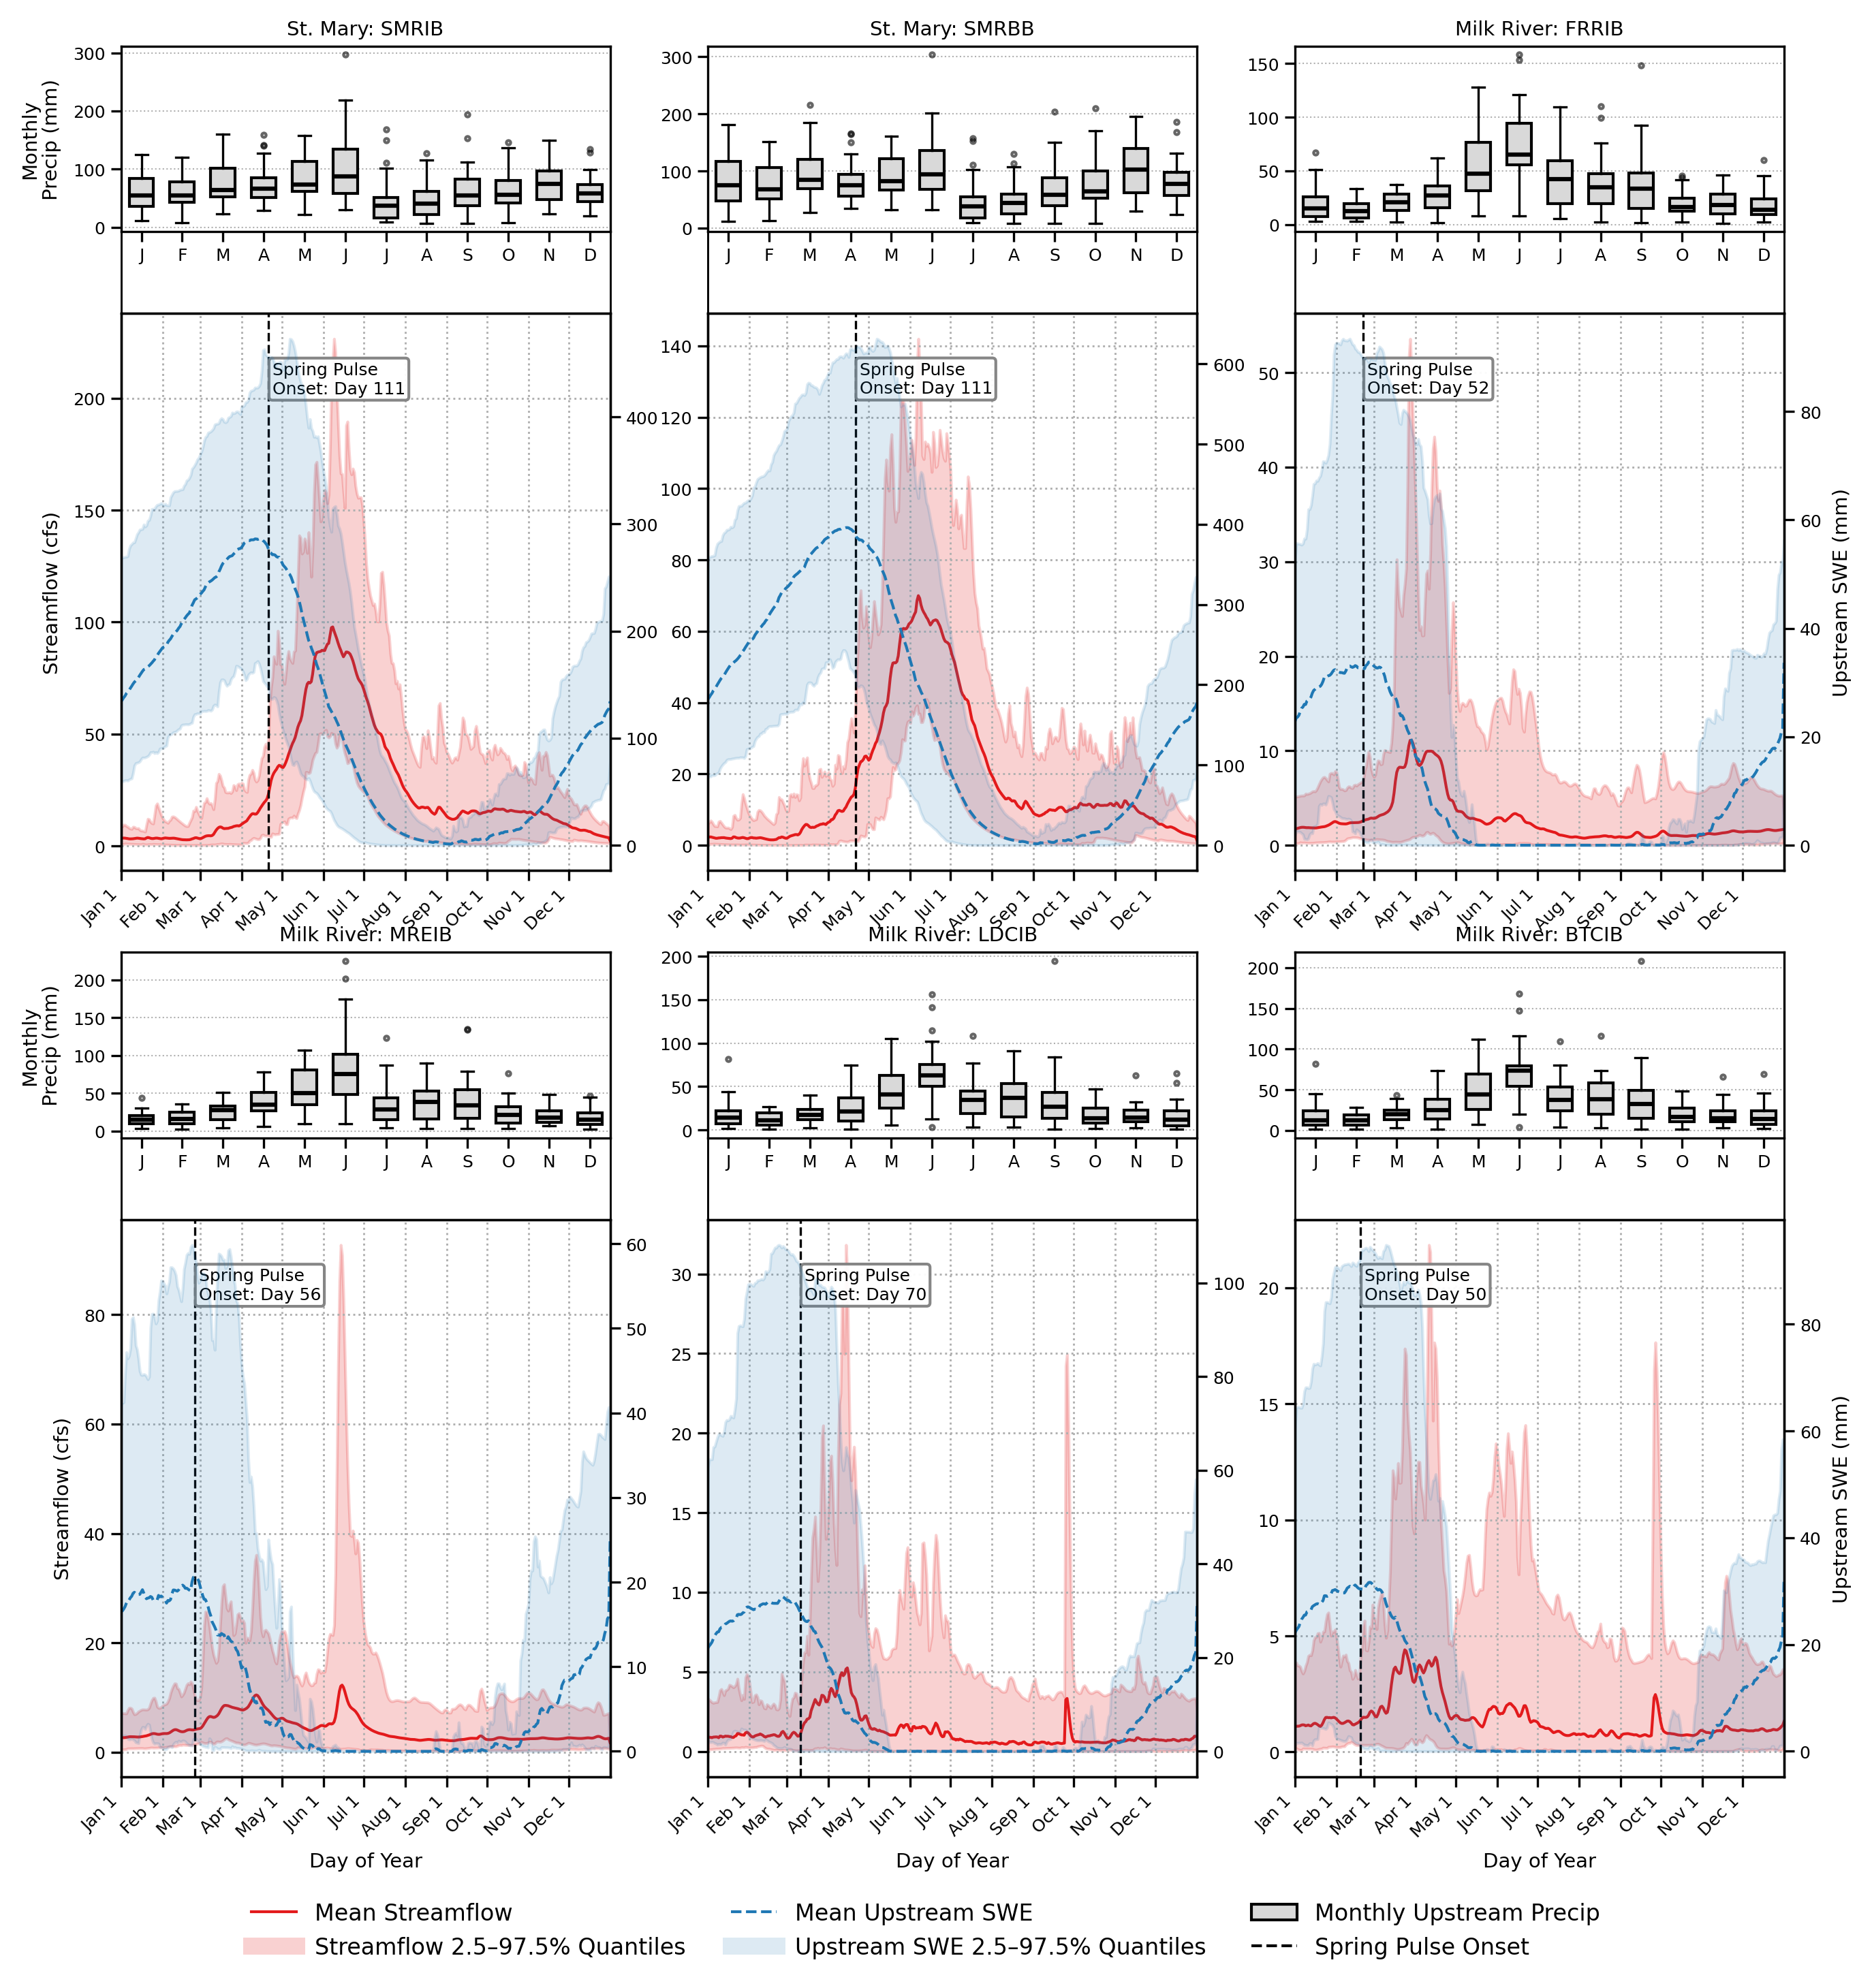

In [24]:
# Process the directory
process_directory_combined_plot(input_directory, output_directory)